<a href="https://colab.research.google.com/github/asipnana/ProjectNLP/blob/main/notebooks/01_eda_preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
!pip install pandas numpy matplotlib seaborn scikit-learn

In [2]:
#Import semua yang diperlukan dulu kings and kweens
#Import all needed libraries
import kagglehub, os, re, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
warnings.filterwarnings('ignore')

In [29]:
#Upload data nya dari kaggle agar recreateable
#Upload data from kaggle for recreatability

path = kagglehub.dataset_download("jocelyndumlao/prdect-id-indonesian-emotion-classification")
# Check path yang digunakan untuk download dataset from kaggle
print("Path to dataset files:", path)

# Check the path to confirm file and foldername
for root, dirs, files in os.walk(path):
    for f in files:
        print(os.path.join(root, f))
# Confirm and Load path for data
print(path)
df = pd.read_csv(f'{path}/Product Reviews Dataset for Emotions Classification Tasks - Indonesian (PRDECT-ID) Dataset/PRDECT-ID Dataset.csv')


Using Colab cache for faster access to the 'prdect-id-indonesian-emotion-classification' dataset.
Path to dataset files: /kaggle/input/prdect-id-indonesian-emotion-classification
/kaggle/input/prdect-id-indonesian-emotion-classification/Product Reviews Dataset for Emotions Classification Tasks - Indonesian (PRDECT-ID) Dataset/PRDECT-ID Dataset.csv
/kaggle/input/prdect-id-indonesian-emotion-classification


In [30]:
print(df.shape)
df.info()
df.columns

(5400, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5400 entries, 0 to 5399
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Category         5400 non-null   object 
 1   Product Name     5400 non-null   object 
 2   Location         5400 non-null   object 
 3   Price            5400 non-null   int64  
 4   Overall Rating   5400 non-null   float64
 5   Number Sold      5400 non-null   int64  
 6   Total Review     5400 non-null   int64  
 7   Customer Rating  5400 non-null   int64  
 8   Customer Review  5400 non-null   object 
 9   Sentiment        5400 non-null   object 
 10  Emotion          5400 non-null   object 
dtypes: float64(1), int64(4), object(6)
memory usage: 464.2+ KB


Index(['Category', 'Product Name', 'Location', 'Price', 'Overall Rating',
       'Number Sold', 'Total Review', 'Customer Rating', 'Customer Review',
       'Sentiment', 'Emotion'],
      dtype='object')

- Column : 11
- Row : 5400

Datatype : float64(1), int64(4), object(6)

Available Columns : 'Category', 'Product Name', 'Location', 'Price', 'Overall Rating','Number Sold', 'Total Review', 'Customer Rating', 'Customer Review','Sentiment', 'Emotion'

Banyak kolom dari setiap data, dan di EDA ini kita harus melihat relasi dan memfilter column yang akan di drop dan digunakan sebagai fitur.

Dilakukan pemeriksaan struktur data, distribusi fitur, kualitas data (missing values dan duplicate), serta hubungan antar variabel. Hasil analisis ini digunakan untuk menentukan fitur yang relevan, mengidentifikasi fitur yang dapat dihapus, dan memahami karakteristik dataset sebelum tahap preprocessing dan pemodelan.

In [31]:
# simpan raw sebelum cleaning untuk bandingin
df_raw = df.copy()

# cek missing values sebelum cleaning
print(df_raw.isnull().sum())
print()
# cek duplikat
print(f'Duplikat: {df_raw.duplicated(subset=["Customer Review"]).sum()}')

Category           0
Product Name       0
Location           0
Price              0
Overall Rating     0
Number Sold        0
Total Review       0
Customer Rating    0
Customer Review    0
Sentiment          0
Emotion            0
dtype: int64

Duplikat: 95


tidak ada missing value, ada 95 row duplikat.

Akan dilakukan basic cleaning (drop duplicate, normalize sentiment dan emotion dengan lower dan strip).

In [33]:
df.columns        = df.columns.str.strip()
df['Sentiment']   = df['Sentiment'].str.lower().str.strip()
df['Emotion']     = df['Emotion'].str.lower().str.strip()

In [34]:
df     = df.drop_duplicates(subset=['Customer Review']).reset_index(drop=True)

# Check shape dari raw dan cleaned.
print(f'Raw shape   : {df_raw.shape}')
print(f'Clean shape : {df.shape}')
print(f'Dropped     : {len(df_raw) - len(df)} rows')

df.head()

Raw shape   : (5400, 11)
Clean shape : (5305, 11)
Dropped     : 95 rows


,Category,Product Name,Location,Price,Overall Rating,Number Sold,Total Review,Customer Rating,Customer Review,Sentiment,Emotion
0,Computers and Laptops,Wireless Keyboard i8 Mini TouchPad Mouse 2.4G ...,Jakarta Utara,53500,4.9,5449,2369,5,Alhamdulillah berfungsi dengan baik. Packaging...,positive,happy
1,Computers and Laptops,PAKET LISENSI WINDOWS 10 PRO DAN OFFICE 2019 O...,Kota Tangerang Selatan,72000,4.9,2359,1044,5,"barang bagus dan respon cepat, harga bersaing ...",positive,happy
2,Computers and Laptops,SSD Midasforce 128 Gb - Tanpa Caddy,Jakarta Barat,213000,5.0,12300,3573,5,"barang bagus, berfungsi dengan baik, seler ram...",positive,happy
3,Computers and Laptops,ADAPTOR CHARGER MONITOR LCD LED TV LG merek LG...,Jakarta Timur,55000,4.7,2030,672,5,bagus sesuai harapan penjual nya juga ramah. t...,positive,happy
4,Computers and Laptops,ADAPTOR CHARGER MONITOR LCD LED TV LG merek LG...,Jakarta Timur,55000,4.7,2030,672,5,"Barang Bagus, pengemasan Aman, dapat Berfungsi...",positive,happy


In [32]:
df_raw.head()

,Category,Product Name,Location,Price,Overall Rating,Number Sold,Total Review,Customer Rating,Customer Review,Sentiment,Emotion
0,Computers and Laptops,Wireless Keyboard i8 Mini TouchPad Mouse 2.4G ...,Jakarta Utara,53500,4.9,5449,2369,5,Alhamdulillah berfungsi dengan baik. Packaging...,Positive,Happy
1,Computers and Laptops,PAKET LISENSI WINDOWS 10 PRO DAN OFFICE 2019 O...,Kota Tangerang Selatan,72000,4.9,2359,1044,5,"barang bagus dan respon cepat, harga bersaing ...",Positive,Happy
2,Computers and Laptops,SSD Midasforce 128 Gb - Tanpa Caddy,Jakarta Barat,213000,5.0,12300,3573,5,"barang bagus, berfungsi dengan baik, seler ram...",Positive,Happy
3,Computers and Laptops,ADAPTOR CHARGER MONITOR LCD LED TV LG merek LG...,Jakarta Timur,55000,4.7,2030,672,5,bagus sesuai harapan penjual nya juga ramah. t...,Positive,Happy
4,Computers and Laptops,ADAPTOR CHARGER MONITOR LCD LED TV LG merek LG...,Jakarta Timur,55000,4.7,2030,672,5,"Barang Bagus, pengemasan Aman, dapat Berfungsi...",Positive,Happy


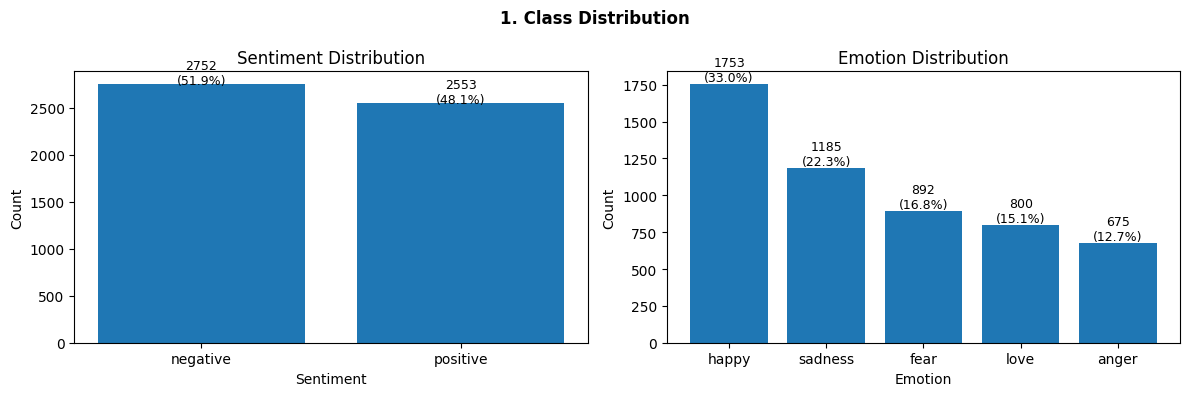

In [48]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('1. Class Distribution', fontweight='bold')

# Lihat kolom Sentiment dan Emotion untuk melihat distribusinya
# Sentiment :
sent_counts = df['Sentiment'].value_counts()

bars = ax[0].bar(sent_counts.index, sent_counts.values)
for bar, val in zip(bars, sent_counts.values):
    ax[0].text(
        # Naro percentage tengah grafik agar terlihat
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f'{val}\n({val/len(df)*100:.1f}%)',
        ha='center',
        fontsize=9
    )

ax[0].set_title('Sentiment Distribution')
ax[0].set_xlabel('Sentiment')
ax[0].set_ylabel('Count')
# Emotion :
emotion_counts = df['Emotion'].value_counts()

bars = ax[1].bar(emotion_counts.index, emotion_counts.values)
for bar, val in zip(bars, emotion_counts.values):
    ax[1].text(
        # Naro percentage tengah grafik agar terlihat
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 20,
        f'{val}\n({val/len(df)*100:.1f}%)',
        ha='center',
        fontsize=9
    )

ax[1].set_title('Emotion Distribution')
ax[1].set_xlabel('Emotion')
ax[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

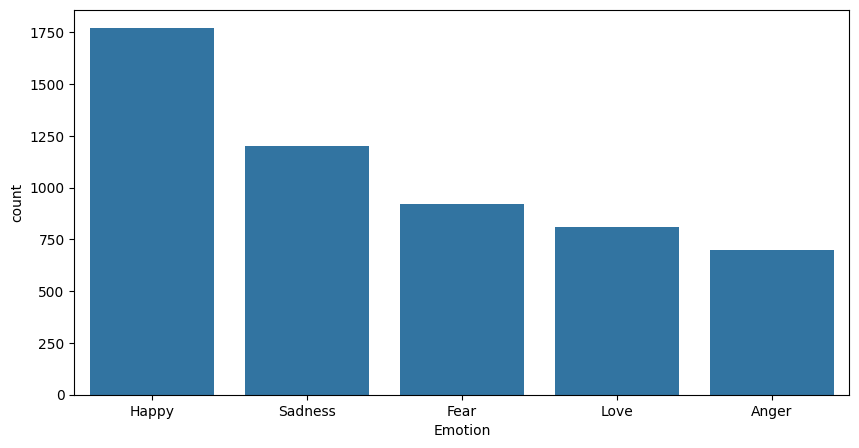